In [32]:
!pip install opencv-python-headless matplotlib -q

In [33]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

print("OpenCV version:", cv2.__version__)
print("NumPy version:", np.__version__)

OpenCV version: 5.0.0
NumPy version: 2.1.3


In [34]:
def color_filter(image):
    hls = cv2.cvtColor(image, cv2.COLOR_BGR2HLS)

    lower_white = np.array([0, 140, 0])
    upper_white = np.array([255, 255, 60])
    white_mask = cv2.inRange(hls, lower_white, upper_white)

    lower_yellow = np.array([15, 30, 100])
    upper_yellow = np.array([35, 204, 255])
    yellow_mask = cv2.inRange(hls, lower_yellow, upper_yellow)

    mask = cv2.bitwise_or(white_mask, yellow_mask)
    filtered = cv2.bitwise_and(image, image, mask=mask)

    return filtered
def canny(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (5, 5), 0)
    edges = cv2.Canny(blur, 50, 150)
    return edges

In [35]:
def region_of_interest(image):
    height = image.shape[0]
    width = image.shape[1]
    mask = np.zeros_like(image)

    polygon = np.array([
        [
            (0, height),
            (0, int(height * 0.55)),
            (width, int(height * 0.55)),
            (width, height)
        ]
    ], dtype=np.int32)

    cv2.fillPoly(
        mask,
        polygon,
        255
    )

    masked_image = cv2.bitwise_and(
        image,
        mask
    )

    return masked_image

In [36]:
def detect_lines(image):

    lines = cv2.HoughLinesP(
        image,
        rho=1,
        theta=np.pi / 180,
        threshold=20,
        minLineLength=20,
        maxLineGap=300
    )

    return lines

In [37]:
def separate_lines(image, lines, verbose=False):

    left_lines = []
    right_lines = []

    if lines is None:
        if verbose:
            print("No lines found by HoughLinesP at all.")
        return left_lines, right_lines

    height, width = image.shape[:2]
    mid_x = width / 2

    for line in lines:

        x1, y1, x2, y2 = np.asarray(line).reshape(-1)

        if x2 == x1:
            continue
        slope = (y2 - y1) / (x2 - x1)

        if abs(slope) < 0.4 or abs(slope) > 3:
            continue

        intercept = y1 - slope * x1

        x_at_bottom = (height - intercept) / slope

        if slope < 0 and x_at_bottom < mid_x:
            left_lines.append((x1, y1, x2, y2))
        elif slope > 0 and x_at_bottom > mid_x:
            right_lines.append((x1, y1, x2, y2))


    if verbose:
        print(f"left segments: {len(left_lines)}, right segments: {len(right_lines)}")

    return left_lines, right_lines

In [38]:
def average_line(image, lines):

    if len(lines) == 0:
        return None

    x_values = []
    y_values = []
    weights = []

    for x1, y1, x2, y2 in lines:

        length = np.sqrt((x2 - x1) ** 2 + (y2 - y1) ** 2)

        x_values.extend([x1, x2])
        y_values.extend([y1, y2])
        weights.extend([length, length])

    if len(x_values) < 2:
        return None

    slope, intercept = np.polyfit(
        x_values,
        y_values,
        1,
        w=weights
    )

    height = image.shape[0]

    y1 = height
    y2 = int(height * 0.60)

    if slope == 0:
        return None

    x1 = int((y1 - intercept) / slope)
    x2 = int((y2 - intercept) / slope)

    return (x1, y1, x2, y2)

In [39]:
def is_solid(lines, coverage_threshold=0.6):

    if not lines:
        return False

    ys = []
    total_length = 0

    for x1, y1, x2, y2 in lines:
        ys.extend([y1, y2])
        total_length += np.hypot(x2 - x1, y2 - y1)

    span = max(ys) - min(ys)

    if span <= 0:
        return False


    coverage = total_length / span

    return coverage >= coverage_threshold

In [40]:
def draw_lane_lines(image, left_line, right_line):

    line_image = np.zeros_like(image)

    if left_line is not None:

        x1, y1, x2, y2 = left_line

        cv2.line(
            line_image,
            (x1, y1),
            (x2, y2),
            (0, 255, 0),
            8
        )

    if right_line is not None:

        x1, y1, x2, y2 = right_line

        cv2.line(
            line_image,
            (x1, y1),
            (x2, y2),
            (0, 255, 0),
            8
        )

    return line_image

In [42]:
def find_lane_center(image, left_line, right_line):

    height, width = image.shape[:2]

    if left_line is None or right_line is None:
        return None

    left_x1, left_y1, left_x2, left_y2 = left_line
    right_x1, right_y1, right_x2, right_y2 = right_line

    left_bottom = left_x1
    right_bottom = right_x1

    lane_center = int(
        (left_bottom + right_bottom) / 2
    )

    image_center = int(width / 2)

    return lane_center, image_center

In [43]:
def draw_lane_center(image, center_data):

    if center_data is None:
        return image

    lane_center, image_center = center_data

    height, width = image.shape[:2]

    cv2.line(
        image,
        (lane_center, height),
        (lane_center, int(height * 0.6)),
        (255, 0, 0),
        5
    )

    cv2.line(
        image,
        (image_center, height),
        (image_center, int(height * 0.6)),
        (0, 0, 255),
        5
    )

    difference = lane_center - image_center

    if abs(difference) < 50:

        position = "CENTER"

    elif difference < 0:

        position = "LEFT"

    else:

        position = "RIGHT"

    cv2.putText(
        image,
        position,
        (50, 80),
        cv2.FONT_HERSHEY_SIMPLEX,
        2,
        (255, 255, 255),
        4
    )

    return image

In [44]:
def lane_detection(image, verbose=False):

    edges = canny(image)
    cropped_edges = region_of_interest(edges)
    lines = detect_lines(cropped_edges)
    left_lines, right_lines = separate_lines(
        image,
        lines,
        verbose=verbose
    )

    left_line = average_line(
        image,
        left_lines
    )

    right_line = average_line(
        image,
        right_lines
    )

    lane_image = draw_lane_lines(
        image,
        left_line,
        right_line
    )

    result = cv2.addWeighted(
        image,
        0.8,
        lane_image,
        1,
        0
    )

    result = draw_lane_label(
        result,
        left_line,
        right_line
    )

    return result

In [46]:
def debug_pipeline(image):

    filtered = color_filter(image)
    edges = canny(image)
    cropped_edges = region_of_interest(edges)
    lines = detect_lines(cropped_edges)


    raw_lines_image = np.zeros_like(image)
    if lines is not None:
        for line in lines:
            x1, y1, x2, y2 = np.asarray(line).reshape(-1)
            cv2.line(raw_lines_image, (x1, y1), (x2, y2), (0, 255, 255), 3)

    plt.figure(figsize=(18, 10))

    plt.subplot(2, 3, 1)
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title("Original")
    plt.axis("off")

    plt.subplot(2, 3, 2)
    plt.imshow(cv2.cvtColor(filtered, cv2.COLOR_BGR2RGB))
    plt.title("Color filter (white+yellow mask)")
    plt.axis("off")

    plt.subplot(2, 3, 3)
    plt.imshow(edges, cmap="gray")
    plt.title("Canny edges (full image)")
    plt.axis("off")

    plt.subplot(2, 3, 4)
    plt.imshow(cropped_edges, cmap="gray")
    plt.title("Edges after ROI mask")
    plt.axis("off")

    plt.subplot(2, 3, 5)
    plt.imshow(cv2.cvtColor(raw_lines_image, cv2.COLOR_BGR2RGB))
    plt.title(f"Raw Hough segments (count: {0 if lines is None else len(lines)})")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

Saving images (2).jfif to images (2) (2).jfif


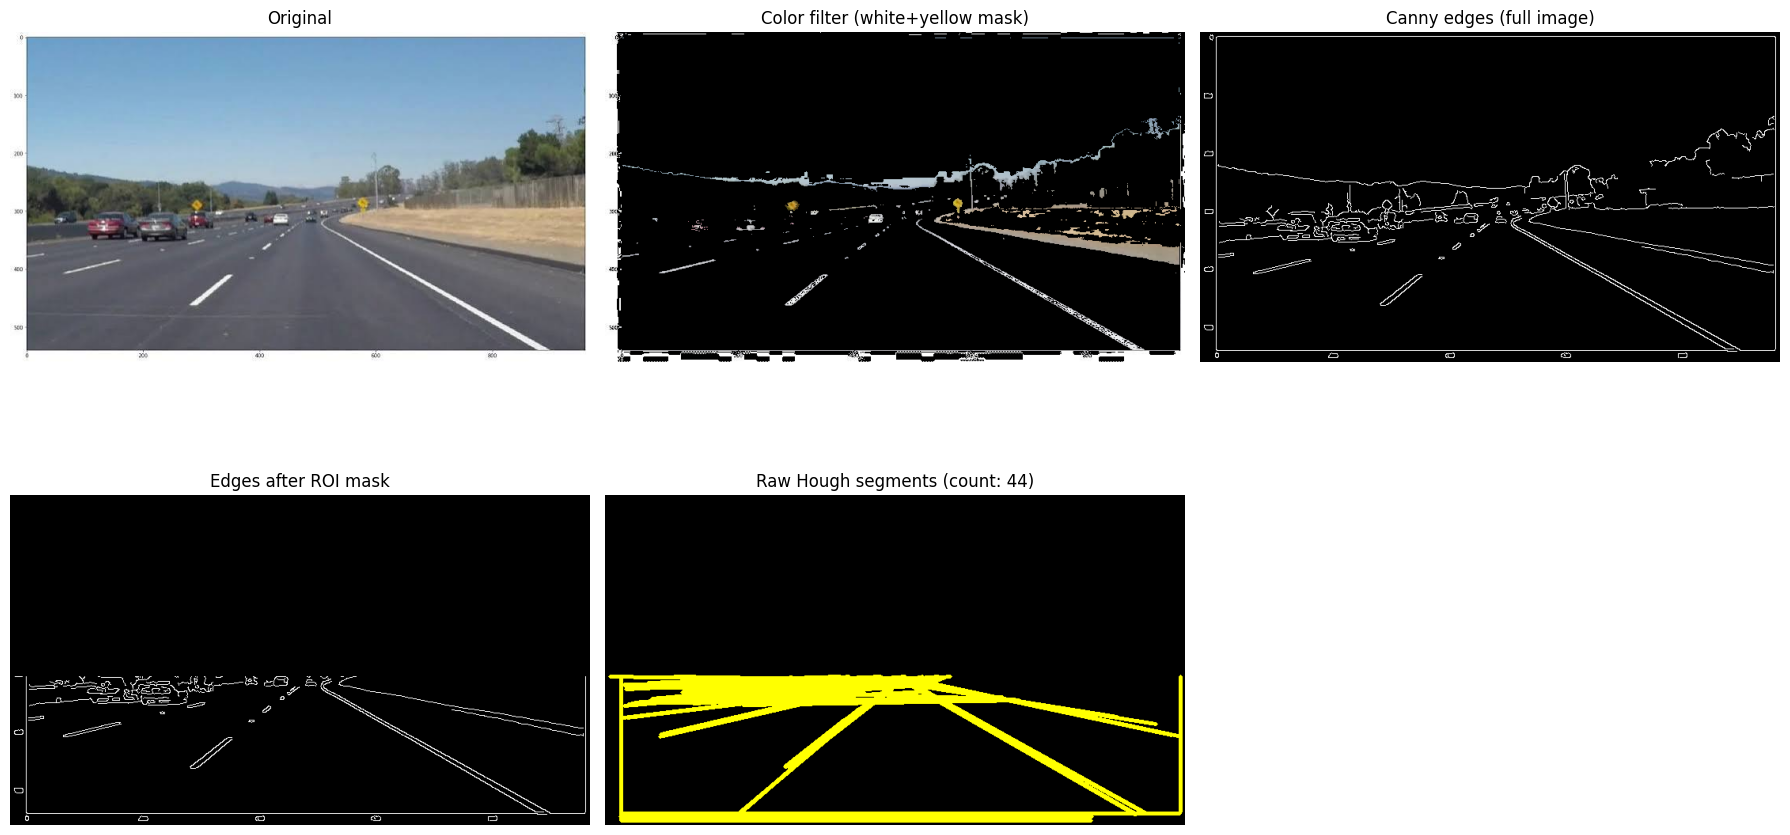

left segments: 5, right segments: 4


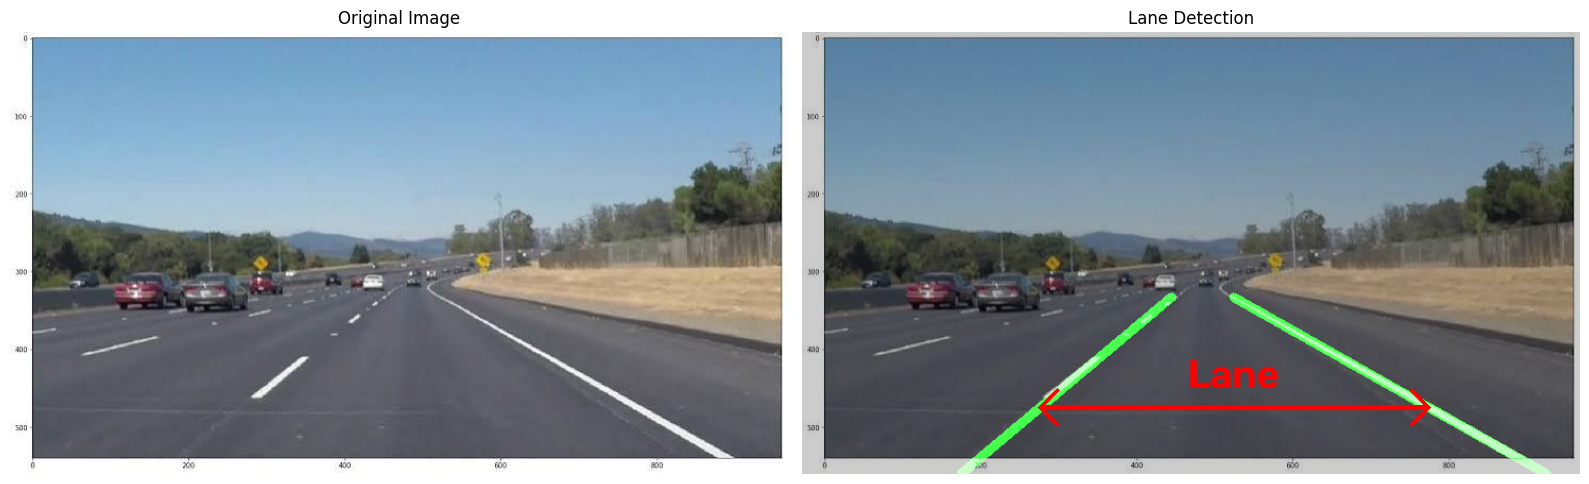

In [47]:
from google.colab import files
uploaded = files.upload()

for filename, file_data in uploaded.items():
    image_bytes = np.frombuffer(
        file_data,
        dtype=np.uint8
    )

    image = cv2.imdecode(
        image_bytes,
        cv2.IMREAD_COLOR
    )

    if image is None:
        print("Could not read image:", filename)
        continue

    debug_pipeline(image)

    result = lane_detection(image, verbose=True)
    original_rgb = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB
    )

    result_rgb = cv2.cvtColor(
        result,
        cv2.COLOR_BGR2RGB
    )

    plt.figure(figsize=(16, 7))

    plt.subplot(1, 2, 1)
    plt.imshow(original_rgb)
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(result_rgb)
    plt.title("Lane Detection")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

In [48]:
from google.colab import files as colab_files

video_uploaded = colab_files.upload()
video_filename = list(video_uploaded.keys())[0]

cap = cv2.VideoCapture(video_filename)

fps = cap.get(cv2.CAP_PROP_FPS)
frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

output_filename = "lane_detection_output.mp4"
fourcc = cv2.VideoWriter_fourcc(*"mp4v")
out = cv2.VideoWriter(output_filename, fourcc, fps, (frame_width, frame_height))

frame_idx = 0

while True:
    ret, frame = cap.read()
    if not ret:
        break

    result_frame = lane_detection(frame, verbose=False)
    out.write(result_frame)

    frame_idx += 1
    if frame_idx % 30 == 0:
        print(f"Processed {frame_idx}/{total_frames} frames")

cap.release()
out.release()

print("Done. Saved to", output_filename)

colab_files.download(output_filename)

Saving watermarked_preview.mp4 to watermarked_preview (3).mp4
Processed 30/326 frames
Processed 60/326 frames
Processed 90/326 frames
Processed 120/326 frames
Processed 150/326 frames
Processed 180/326 frames
Processed 210/326 frames
Processed 240/326 frames
Processed 270/326 frames
Processed 300/326 frames
Done. Saved to lane_detection_output.mp4


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>